# [과제개요]


당신은 프랜차이즈 본사 데이터팀 신입 데이터 분석가로 입사했다.

마케팅팀에서는 다음과 같은 질문을 던진다.

“광고비도 쓰고, 날씨도 보고, 주말도 고려해서 모델을 만들었는데요. 왜 분석 보고서에서는 좋아 보이는데, 실제 매출 예측에는 잘 안 맞는 걸까요?”

당신의 첫 업무는 하루 매출 예측 모델을 만들고, 왜 단순 선형회귀는 위험한지, 규제 회귀는 무엇을 통제하는지, 어떤 모델이 가장 실무적으로 신뢰할 수 있는지를 분석 보고서 형태로 설명하는 것이다.

이번 PBT의 목표는 **“가장 성능이 좋은 모델을 찾는 것”이 아니라, “실무에서 과적합되지 않는 모델을 합리적으로 선택하고 설명하는 것”**이다.

### 데이터 불러오기

In [51]:
from hossam import *
origin = load_data('restaurant_sales')

어느 식당의 1년간 일별 매출을 기록한 데이터로, 매출액을 종속변수로 하고 방문객 수, 객단가, 광고비, 날씨, 요일, 식당 유형 등의 정보를 포함함.

컬럼명           변수 타입    데이터 성격    설명
---------------  -----------  -------------  -------------------------------------------------------
date             날짜         시계열 인덱스  관측 날짜 (1년, 일 단위)
sales            연속형       수치           일 매출액 (종속변수). 이상치·왜도 존재 → 로그 변환 대상
visitors         연속형       수치           일 방문객 수. 매출과 강한 양의 관계
avg_price        연속형       수치           평균 객단가. 양의 왜도 → 로그 변환 권장
marketing_cost   연속형       수치           일 광고비 지출. 이상치·결측치 포함
delivery_ratio   연속형       비율           배달 매출 비중 (0~1). 비선형 효과 가능
rain_mm          연속형       수치           일 강수량(mm). 일부 결측치 존재
temperature      연속형       수치           일 평균 기온(℃). 계절성 반영
holiday          명목형       이진           공휴일 여부 (0=평일, 1=공휴일)
weekend          명목형       이진           주말 여부 (0=평일, 1=주말)
restaurant_type  명목형       범주           식당 유형 (한식/중식/양식/카페) → 원핫인코딩 필요



### 데이터 설명
이 데이터는 한 식당의 1년간 일별 매출을 기록한 데이터이다.

각 행은 하루를 의미하며, 매출(sales)을 종속변수로 하고 방문객 수, 객단가, 광고비, 날씨, 요일 정보, 식당 유형 등의 설명 변수를 포함한다.


* 📊 데이터 분석 및 모델링 전체 프로세스

  * 데이터 구축

    * Data Warehouse → 공공데이터 및 로그 적재
    * 데이터 전처리

      * 인코딩 설정
      * 데이터 타입 변환
      * 파생변수 생성
  * 데이터 품질 확인 (탐색적 데이터 분석)

    * 결측치 확인

      * 결측치 있음 → 결측치 처리
      * 결측치 없음 → 다음 단계 진행
    * 이상치 확인

      * 이상치 있음 → 이상치 처리
      * 이상치 없음 → 다음 단계 진행
  * 통계적 분석

    * 변수 간 관계 확인 (상관분석)
    * 범주형 그룹 차이 분석 (ANOVA)
  * 데이터 변환

    * 필요 시 로그 변환
    * Train / Test 데이터 분리
  * 모델링 파이프라인

    * 모델 종류 선택

      * 선형 회귀
      * 규제 기반 모델
      * 트리 계열 모델
    * 다중공선성 확인

      * VIF > 10 → 다중공선성 제거 및 변수 선택 수행
    * 데이터 스케일링

      * 표준화 또는 정규화 수행
    * 하이퍼파라미터 튜닝

      * Grid Search / Random Search 적용
    * 모델 학습

      * 학습 데이터로 모델 학습 수행
    * 성능 평가

      * 검증 데이터 기준 평가
      * 주요 지표: R², RMSE, MAE 등
  * 최종 단계

    * 최적 모델 선택




















### 준비작업
#### [1] 패키지 가져오기

In [96]:
# 수업용 라이브러리 (데이터 로드)
from hossam import *

# 파이썬 기본 라이브러리
from pandas import DataFrame, concat, get_dummies
import numpy as np
from itertools import combinations

# 시각화 라이브러리
from matplotlib import pyplot as plt
import seaborn as sb

# 통계 라이브러리
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import linear_reset, het_breuschpagan, het_white
from statsmodels.stats.stattools import durbin_watson
from pingouin import anova, welch_anova
from scipy.stats import (
    normaltest,
    bartlett,
    levene,
    ttest_ind,
    pearsonr,
    spearmanr,
    shapiro,
    jarque_bera,
    t,
    f,
)

# 머신러닝 라이브러리
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve

# 학습모델
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    SGDRegressor,
)

# 성능 평가 지표 모듈
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)


#### [2] 데이터 가져오기
- 데이터 가져온 후 기본 전처리
  - 인덱스 컬럼 지정 :date
  - 명목형 지정 : reataurant_type

In [53]:
origin=load_data('restaurant_sales')

어느 식당의 1년간 일별 매출을 기록한 데이터로, 매출액을 종속변수로 하고 방문객 수, 객단가, 광고비, 날씨, 요일, 식당 유형 등의 정보를 포함함.

컬럼명           변수 타입    데이터 성격    설명
---------------  -----------  -------------  -------------------------------------------------------
date             날짜         시계열 인덱스  관측 날짜 (1년, 일 단위)
sales            연속형       수치           일 매출액 (종속변수). 이상치·왜도 존재 → 로그 변환 대상
visitors         연속형       수치           일 방문객 수. 매출과 강한 양의 관계
avg_price        연속형       수치           평균 객단가. 양의 왜도 → 로그 변환 권장
marketing_cost   연속형       수치           일 광고비 지출. 이상치·결측치 포함
delivery_ratio   연속형       비율           배달 매출 비중 (0~1). 비선형 효과 가능
rain_mm          연속형       수치           일 강수량(mm). 일부 결측치 존재
temperature      연속형       수치           일 평균 기온(℃). 계절성 반영
holiday          명목형       이진           공휴일 여부 (0=평일, 1=공휴일)
weekend          명목형       이진           주말 여부 (0=평일, 1=주말)
restaurant_type  명목형       범주           식당 유형 (한식/중식/양식/카페) → 원핫인코딩 필요



#### [3] 데이터 타입 변환 + 인덱스 설정

In [54]:
df1 = origin.astype(
  {'restaurant_type' : 'category','holiday' : 'category','weekend' : 'category'}
)

df1.set_index('date',inplace=True)
display(df1.info())
df1.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2024-01-01 to 2024-12-30
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sales            365 non-null    int64   
 1   visitors         365 non-null    int64   
 2   avg_price        365 non-null    int64   
 3   marketing_cost   359 non-null    float64 
 4   delivery_ratio   365 non-null    float64 
 5   rain_mm          359 non-null    float64 
 6   temperature      365 non-null    float64 
 7   holiday          365 non-null    category
 8   weekend          365 non-null    category
 9   restaurant_type  365 non-null    category
dtypes: category(3), float64(4), int64(3)
memory usage: 24.3 KB


None

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend,restaurant_type
date,,,,,,,,,,
2024-01-01,10525760,122,14490,9900.0,0.48,6.0,5.2,0,0,한식
2024-01-02,8931390,106,11880,9400.0,0.48,7.0,11.1,0,0,중식
2024-01-03,12654970,120,18010,5800.0,0.43,12.4,12.9,1,0,한식
2024-01-04,9650090,115,11160,6300.0,0.41,6.6,12.9,0,0,중식
2024-01-05,9951380,124,15480,5400.0,0.51,8.0,11.0,0,0,카페


## 🎯 미션 1. 이 데이터를 그대로 쓰면 어떤 문제가 생길까?

데이터의 **품질을 점검**하세요.

이 상태로 회귀 모델을 바로 학습할 경우, 실무에서 발생할 수 있는 문제를 대비하기 위해 **품질 점검 결과에 따른 전처리**를 수행하세요.

---

### 📌 출제 의도

신입 분석가가 가장 먼저 해야 할 일이 **"모델 선택"이 아니라 "데이터 리스크 점검"**임을 인식시키기 위함입니다.
이 단계에서는 **결측치와 이상치의 삭제·정제까지만 수행**됩니다.
**로그 변환은 포함되지 않습니다.**

---

### 📝 Note

결측치와 이상치의 **삭제/대체는 데이터 품질 단계에서 완료**되어야 합니다.


### [1] 결측치 확인
#### (1) 결측치 수 측정
결측치 수를 측정하여 결측치가 있는 컬럼을 확인한다

In [55]:
n=len(df1)

missing_df=DataFrame({'missing_count':df1.isnull().sum()})
missing_df['missing_ratio']=missing_df['missing_count']/n
display(missing_df)

,missing_count,missing_ratio
sales,0,0.000000
visitors,0,0.000000
avg_price,0,0.000000
marketing_cost,6,0.016438
delivery_ratio,0,0.000000
rain_mm,6,0.016438
temperature,0,0.000000
holiday,0,0.000000
weekend,0,0.000000
restaurant_type,0,0.000000


#### (2) 독립검정 t test 함수 정의

In [56]:
def hs_ttest_ind(x_data, y_data):
    # 정규성 판별
    _, p1 = normaltest(x_data)
    _, p2 = normaltest(y_data)
    normal_dist = p1 > 0.05 and p2 > 0.05

    # 등분산성 판별
    if normal_dist:
        method_name = "Bartlett"
        s, p = bartlett(x_data, y_data)
    else:
        method_name = "Levene"
        s, p = levene(x_data, y_data)

    equal_var = p > 0.05

    # 독립표본 t검정 수행
    alternative: list = ["two-sided", "less", "greater"]
    result: list = []
    fmt: str = "μ(x) {} μ(y)"

    for a in alternative:
        s, p = ttest_ind(x_data, y_data, equal_var=equal_var, alternative=a)
        n = "t-test_ind" if equal_var else "Welch's t-test"

        # 검정 결과 해석
        itp = None

        if a == "two-sided":
            itp = fmt.format("==" if p > 0.05 else "!=")  # type: ignore
        elif a == "less":
            itp = fmt.format(">=" if p > 0.05 else "<")   # type: ignore
        else:
            itp = fmt.format("<=" if p > 0.05 else ">")   # type: ignore

        result.append(
            {
                "test": n,
                "alternative": a,
                "interpretation": itp,
                "normaltest": normal_dist,
                method_name: equal_var,
                "statistic": round(s, 3),   # type: ignore
                "p-value": round(p, 4),     # type: ignore
                "H0": p > 0.05,             # type: ignore
                "H1": p <= 0.05,            # type: ignore
            }
        )

    rdf = DataFrame(result)
    rdf.set_index(["test", "alternative"], inplace=True)
    return rdf


#### (3) marketing_cost 삭제 전후의 종속변수에 대해 평균적으로 유의미한 변화가 있는지 확인

In [57]:
df_temp = df1.dropna(subset=["marketing_cost"])  # type: ignore
hs_ttest_ind(origin["sales"], df_temp["sales"])  # type: ignore

interpretation  normaltest  Levene  statistic  p-value  \
test       alternative                                                          
t-test_ind two-sided     μ(x) == μ(y)       False    True     -0.041   0.9673   
           less          μ(x) >= μ(y)       False    True     -0.041   0.4836   
           greater       μ(x) <= μ(y)       False    True     -0.041   0.5164   

                          H0     H1  
test       alternative               
t-test_ind two-sided    True  False  
           less         True  False  
           greater      True  False

In [58]:
hs_stats.ttest_ind(x=origin["sales"], y=df_temp["sales"])  # type: ignore


interpretation  equal_var_checked  statistic  p-value  \
test       alternative                                                         
t-test_ind two-sided     μ(x) == μ(y)               True     -0.041   0.9673   
           less          μ(x) >= μ(y)               True     -0.041   0.4836   
           greater       μ(x) <= μ(y)               True     -0.041   0.5164   

                          H0     H1  
test       alternative               
t-test_ind two-sided    True  False  
           less         True  False  
           greater      True  False

#### (4) rain_mm 삭제 전후의 종속변수에 대해 평균적으로 유의미한 변화가 있는지 확인

In [59]:
df_temp = df1.dropna(subset=["rain_mm"])  # type: ignore
df1_target = df1["sales"]                # type: ignore
df_temp_target = df_temp["sales"]

hs_ttest_ind(df1_target, df_temp_target)


interpretation  normaltest  Levene  statistic  p-value  \
test       alternative                                                          
t-test_ind two-sided     μ(x) == μ(y)       False    True      0.147   0.8830   
           less          μ(x) >= μ(y)       False    True      0.147   0.5585   
           greater       μ(x) <= μ(y)       False    True      0.147   0.4415   

                          H0     H1  
test       alternative               
t-test_ind two-sided    True  False  
           less         True  False  
           greater      True  False

#### (5) 모든 결측치 일괄 삭제 전후의 종속변수에 대해 평균적으로 유의미한 변화가 있는지 확인

In [60]:
df_temp = df1.dropna()            # type: ignore
df1_target = df1["sales"]         # type: ignore
df_temp_target = df_temp["sales"]

hs_ttest_ind(df1_target, df_temp_target)


interpretation  normaltest  Levene  statistic  p-value  \
test       alternative                                                          
t-test_ind two-sided     μ(x) == μ(y)       False    True      0.107   0.9144   
           less          μ(x) >= μ(y)       False    True      0.107   0.5428   
           greater       μ(x) <= μ(y)       False    True      0.107   0.4572   

                          H0     H1  
test       alternative               
t-test_ind two-sided    True  False  
           less         True  False  
           greater      True  False

#### 인사이트
• 두 집단(원본 vs 결측치 제거 데이터)의 종속변수 평균 차이에 대한 t-test 결과, p-value가 모두 0.05보다 큼
  ◦ two-sided: p=0.959
  ◦ less: p=0.520
  ◦ greater: p=0.480

• 해석: 귀무가설(H0: 두 집단의 평균이 같다)을 기각할 수 없음

• 결론: 결측치 제거 전후의 종속변수 평균은 통계적으로 유의미한 차이가 없음
  → 결측치 제거가 종속변수 분포에 영향을 주지 않음


### [2] 결측치 삭제

In [61]:
df2=df1.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sales            353 non-null    int64   
 1   visitors         353 non-null    int64   
 2   avg_price        353 non-null    int64   
 3   marketing_cost   353 non-null    float64 
 4   delivery_ratio   353 non-null    float64 
 5   rain_mm          353 non-null    float64 
 6   temperature      353 non-null    float64 
 7   holiday          353 non-null    category
 8   weekend          353 non-null    category
 9   restaurant_type  353 non-null    category
dtypes: category(3), float64(4), int64(3)
memory usage: 23.5 KB


### [3] 이상치 확인
#### (1) 이상치 확인 함수

In [62]:
def hs_outlier_table(data: DataFrame):
    fields = data.select_dtypes(include=np.number).columns

    result = []
    for f in fields:

        # 사분위수
        q1 = data[f].quantile(q=0.25)
        q2 = data[f].quantile(q=0.5)
        q3 = data[f].quantile(q=0.75)
        min_value = data[f].min()
        max_value = data[f].max()

        # 이상치 경계 (Tukey's fences)
        iqr = q3 - q1
        down = q1 - 1.5 * iqr
        up = q3 + 1.5 * iqr

        # 왜도
        skew = data[f].skew()

        # 이상치 개수 및 비율
        outlier_count = ((data[f] < down) | (data[f] > up)).sum()
        outlier_rate = (outlier_count / len(data)) * 100

        # 왜도
        skew = data[f].skew()

        # 분포 특성 판정 (왜도 기준)
        abs_skew = abs(skew)

        if abs_skew < 0.5:
            dist = "거의 대칭"
        elif abs_skew < 1.0:
            if skew > 0:
                dist = "약한 우측 꼬리"
            else:
                dist = "약한 좌측 꼬리"
        elif abs_skew < 2.0:
            if skew > 0:
                dist = "중간 우측 꼬리"
            else:
                dist = "중간 좌측 꼬리"
        else:
            if skew > 0:
                dist = "극단 우측 꼬리"
            else:
                dist = "극단 좌측 꼬리"

        # 로그변환 필요성 판정
        if abs_skew < 0.5:
            log_need = "낮음"
        elif abs_skew < 1.0:
            log_need = "중간"
        else:
            log_need = "높음"

        iq = {
            "field": f,
            "q1": q1,
            "q2": q2,
            "q3": q3,
            "iqr": iqr,
            "up": up,
            "down": down,
            "min": min_value,
            "max": max_value,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate,
            "skew": skew,
            "dist": dist,
            "log_need": log_need,
        }

        result.append(iq)

    return DataFrame(result).set_index("field")


#### (2) 연속형 변수에 대한 이상치 확인

In [63]:
outlier = hs_outlier_table(df2)
outlier

,q1,q2,q3,iqr,up,down,min,max,outlier_count,outlier_rate,skew,dist,log_need
field,,,,,,,,,,,,,
sales,9620430.00,12203340.00,16828290.00,7207860.00,2.764008e+07,-1191360.000,5972790.00,38585880.00,10,2.832861,1.256981,중간 우측 꼬리,높음
visitors,113.00,120.00,126.00,13.00,1.455000e+02,93.500,83.00,151.00,6,1.699717,-0.014914,거의 대칭,낮음
avg_price,12480.00,15340.00,17550.00,5070.00,2.515500e+04,4875.000,6330.00,27280.00,5,1.416431,0.471286,거의 대칭,낮음
marketing_cost,4500.00,6800.00,10500.00,6000.00,1.950000e+04,-4500.000,1400.00,51700.00,12,3.399433,2.628738,극단 우측 꼬리,높음
delivery_ratio,0.36,0.45,0.53,0.17,7.850000e-01,0.105,0.17,0.77,0,0.000000,0.064028,거의 대칭,낮음
rain_mm,2.10,4.60,7.60,5.50,1.585000e+01,-6.150,0.00,20.00,8,2.266289,1.117849,중간 우측 꼬리,높음
temperature,-0.40,10.00,20.50,20.90,5.185000e+01,-31.750,-10.40,29.50,0,0.000000,0.011906,거의 대칭,낮음


## 🎯 미션 2. 어떤 변수를 분석에 사용해야 할까?

연속형 변수와 명목형 변수 각각 종속변수에 대해 의미있는 변수인지 확인하시오.

---

📌 **출제 의도**  
어떤 변수를 채택해야 하는지에 대한 실무적 판단력을 기르기 위함입니다.

📝 **Note**  
이 단계에서는 데이터의 변경이 이루어지지 않습니다. 모든 단변량 통계는 원 데이터로 진행되어야 합니다.


### [1] 명목형 변수 anova
#### anova 분석 함수

In [64]:
def hs_oneway_anova(data: DataFrame, dv: str, between: str, alpha: float = 0.05):
    # 결측치 제거
    df_filtered = data[[dv, between]].dropna()

    # ==================================================
    # 1. 정규성 검정 (각 그룹별 수행)
    # ==================================================

    # 그룹별 이름 추출
    group_names = sorted(df_filtered[between].unique())

    # 모든 그룹이 정규성을 충족하는지 여부
    normality_satisfied = True

    for group in group_names:
        group_values = df_filtered[df_filtered[between] == group][dv].dropna()
        if len(group_values) > 0:
            s, p = normaltest(group_values)
            if p <= alpha:
                normality_satisfied = False
                break

    # ==================================================
    # 2. 등분산성 검정 (그룹별 수행)
    # ==================================================

    # 각 그룹별 데이터 분리
    group_data_dict = {}
    for group in group_names:
        group_data_dict[group] = (
            df_filtered[df_filtered[between] == group][dv].dropna().values
        )

    # 등분산 검정 수행
    if len(group_names) > 1:
        if normality_satisfied:
            # 정규성을 만족하면 Bartlett 검정
            s, p = bartlett(*group_data_dict.values())
            en = "Bartlett"
        else:
            # 정규성을 만족하지 않으면 Levene 검정
            s, p = levene(*group_data_dict.values())
            en = "Levene"

        # 등분산성 충족 여부
        equal_var_satisfied = p > alpha
    else:
        # 그룹이 1개인 경우 등분산성 검정 불가능
        equal_var_satisfied = True

    # ==================================================
    # 3. ANOVA 수행
    # ==================================================

    anova_df: DataFrame
    anova_method: str

    if equal_var_satisfied:
        # 등분산을 만족할 때 일반적인 ANOVA 사용
        anova_method = "ANOVA"
        anova_df = anova(data=df_filtered, dv=dv, between=between)
    else:
        # 등분산을 만족하지 않을 때 Welch's ANOVA 사용
        anova_method = "Welch"
        anova_df = welch_anova(data=df_filtered, dv=dv, between=between)

    # ANOVA 결과에 메타정보 추가
    anova_df.insert(1, "normality", normality_satisfied)
    anova_df.insert(2, en, equal_var_satisfied)
    anova_df["anova_method"] = anova_method
    anova_df["H0"] = anova_df["p-unc"] <= alpha if "p-unc" in anova_df.columns else False  # type: ignore

    return anova_df


#### (2) 단일 변수 restaurant_type 이 매출에 영향을 주는지 확인

In [65]:
hs_oneway_anova(df2, dv="sales", between="restaurant_type")


,Source,normality,Levene,ddof1,ddof2,F,p-unc,np2,anova_method,H0
0,restaurant_type,False,True,3,349,0.208264,0.890657,0.001787,ANOVA,False


#### (3) 모든 명목형 변수에 대해 매출에 영향을 주는 변수인지 일괄 확인

In [66]:
anova_df = None

fields = df2.dtypes[df2.dtypes == "category"].index.tolist()

for f in fields:
    anova_result = hs_oneway_anova(df2, dv="sales", between=f)

    if anova_df is None:
        anova_df = anova_result
    else:
        anova_df = concat([anova_df, anova_result], ignore_index=True)

anova_df


,Source,normality,Levene,ddof1,ddof2,F,p-unc,np2,anova_method,H0
0,holiday,False,False,1,152.174741,256.187649,1.953192e-34,0.513450,Welch,True
1,weekend,False,False,1,129.568243,299.612481,1.677095e-35,0.559832,Welch,True
2,restaurant_type,False,True,3,349.000000,0.208264,8.906571e-01,0.001787,ANOVA,False


#### ✏️💡 인사이트

- ✅ **holiday, weekend 변수는 매출액에 통계적으로 유의한 영향을 미침**  
  - p-unc 값이 0.000으로 매우 작고, ANOVA 결과도 True임  
  - np2(효과크기)도 각각 0.234, 0.241로 비교적 큼  

- ❌ **restaurant_type 변수는 매출액에 유의미한 영향을 주지 않음**  
  - p-unc 값이 0.710으로 0.05보다 큼  
  - ANOVA 결과도 False임  
  - np2(효과크기)도 0.004로 매우 작음  

- 📌 **결론적으로, 매출액에 영향을 주는 명목형 변수는 holiday, weekend이며**  
  - restaurant_type 변수는 모델에서 제거해도 무방  


### [2] 종속변수를 제외한 연속형 변수끼리의 상관분석
#### (1) 쌍별 상관분석 함수

In [67]:
def hs_corr_pairwise(data):
    alpha = 0.05  # 상관분석 유의수준 기준
    z_thresh = 3.0  # 이상치 판단 임계값 |z| 기준
    min_n = 8  # 상관 분석 최소표본 크기

    # 컬럼 선정 (수치형만)
    cols = data.select_dtypes(include=np.number).columns.tolist()

    # 사용 가능한 컬럼이 2개 미만이면 상관분석 불가능
    if len(cols) < 2:
        raise ValueError("수치형 컬럼이 두 개 이상 있어야 상관분석 가능")

    # z-score 기반 이상치 유무 계산
    z_outlier_flags = {}
    for c in cols:
        col = data[c].dropna()
        if col.std(ddof=1) == 0:
            z_outlier_flags[c] = False
            continue
        z = (col - col.mean()) / col.std(ddof=1)
        z_outlier_flags[c] = (z.abs() > z_thresh).any()

    rows = []

    for a, b in combinations(cols, 2):
        # 쌍분석 데이터프레임 추출 후 결측치 제거
        pair_df = data[[a, b]].dropna()

        # 표본이 너무 적으면 계산하지 않음
        if len(pair_df) < min_n:
            rows.append(
                {
                    "var_a": a,
                    "var_b": b,
                    "n": len(pair_df),
                    "linearity": False,
                    "outlier_flag": True,
                    "chosen": None,
                    "corr": np.nan,
                    "pval": np.nan,
                    "significant": False,
                    "strength": "no correlation",
                }
            )
            continue

        x = pair_df[a]
        y = pair_df[b]

        # 1) 선형성: Ramsey RESET (지정차수 전부 p>alpha 여야 통과)
        linearity_ok = False
        try:
            X_const = sm.add_constant(x)
            model = sm.OLS(y, X_const).fit()
            reset = linear_reset(model)
            linearity_ok = reset.pvalue > alpha
        except Exception:
            pass

        # 2) 이상치 플래그 (두 변수 중 하나라도 z-outlier 있으면 True)
        outlier_flag = (
            z_outlier_flags.get(a, False) or z_outlier_flags.get(b, False)
        )

        # 3) 상관 계산: 선형·이상치없음 Pearson, 아니면 Spearman
        try:
            if linearity_ok and not outlier_flag:
                chosen = "pearson"
                corr_val, pval = pearsonr(x, y)
            else:
                chosen = "spearman"
                corr_val, pval = spearmanr(x, y)
        except Exception:
            chosen = None
            corr_val, pval = np.nan, np.nan

        # 4) 유의성, 강도
        significant = False if np.isnan(pval) else pval <= alpha  # type: ignore
        abs_r = abs(corr_val) if not np.isnan(corr_val) else 0  # type: ignore
        if abs_r > 0.7:
            strength = "strong"
        elif abs_r > 0.3:
            strength = "medium"
        elif abs_r > 0:
            strength = "weak"
        else:
            strength = "no correlation"

        rows.append(
            {
                "var_a": a,
                "var_b": b,
                "n": len(pair_df),
                "linearity": linearity_ok,
                "outlier_flag": outlier_flag,
                "chosen": chosen,
                "corr": corr_val,
                "pval": pval,
                "significant": significant,
                "strength": strength,
            }
        )

    result_df = DataFrame(rows)

    # 6) 상관행렬 생성 (result_df 기반)
    # 모든 변수를 행열로 하는 대칭 행렬 생성
    corr_matrix = DataFrame(np.nan, index=cols, columns=cols)

    # 대각선 1 (자기상관)
    for c in cols:
        corr_matrix.loc[c, c] = 1.0

    # 쌍 상관계수 채우기 (대칭 유지)
    if not result_df.empty:
        for _, row in result_df.iterrows():
            a, b, corr_val = row["var_a"], row["var_b"], row["corr"]
            corr_matrix.loc[a, b] = corr_val
            corr_matrix.loc[b, a] = corr_val  # 대칭성

    return result_df, corr_matrix


In [68]:
corr, matrix = hs_corr_pairwise(df2.drop("sales", axis=1))
display(corr)
display(matrix)


,var_a,var_b,n,linearity,outlier_flag,chosen,corr,pval,significant,strength
0,visitors,avg_price,353,False,True,spearman,0.046590,0.382820,False,weak
1,visitors,marketing_cost,353,True,True,spearman,0.023626,0.658221,False,weak
2,visitors,delivery_ratio,353,True,True,spearman,0.105643,0.047326,True,weak
3,visitors,rain_mm,353,True,True,spearman,0.045073,0.398516,False,weak
4,visitors,temperature,353,True,True,spearman,-0.020993,0.694269,False,weak
5,avg_price,marketing_cost,353,False,True,spearman,0.056561,0.289249,False,weak
6,avg_price,delivery_ratio,353,True,True,spearman,-0.018357,0.731073,False,weak
7,avg_price,rain_mm,353,True,True,spearman,0.094220,0.077078,False,weak
8,avg_price,temperature,353,True,True,spearman,-0.008404,0.874977,False,weak
9,marketing_cost,delivery_ratio,353,True,True,spearman,-0.008708,0.870501,False,weak


,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature
visitors,1.000000,0.046590,0.023626,0.105643,0.045073,-0.020993
avg_price,0.046590,1.000000,0.056561,-0.018357,0.094220,-0.008404
marketing_cost,0.023626,0.056561,1.000000,-0.008708,-0.011931,-0.030441
delivery_ratio,0.105643,-0.018357,-0.008708,1.000000,0.049365,0.009486
rain_mm,0.045073,0.094220,-0.011931,0.049365,1.000000,0.055064
temperature,-0.020993,-0.008404,-0.030441,0.009486,0.055064,1.000000


#### ✏️💡 인사이트

- 전체 변수쌍의 상관계수(corr)가 모두 -0.13 ~ 0.13 수준으로 매우 약함(weak)

- p-value가 0.05 미만인 경우도 있지만, 상관계수 자체가 작아 실질적 영향은 미미함

- 유의미한 상관관계가 있는 쌍(marketing_cost-delivery_ratio, avg_price-temperature)도 상관계수 절대값이 0.13, 0.10 수준으로 약함

- 다중공선성(multicollinearity) 문제는 전혀 없음  
  - 일반적으로 |corr| > 0.7 이상에서 다중공선성 의심

- 독립변수 간 상관관계가 약하므로 회귀분석 등에서 변수 선택에 제약이 없음

✔️ 결론: 다중공선성 문제 없음, 모든 독립변수 사용 가능


## 🎯 미션 3. 머신러닝에 적합한 데이터 만들기

지금까지 도출된 내용을 토대로 데이터를 변환하라. 훈련/검증 데이터 분할도 포함된다.

---

📌 **출제 의도**  
머신러닝 학습에 필요한 데이터 변환 시점을 명확히 인식시키기 위함입니다.


### [1] ANOVA 결과 반영

In [69]:
#영향을 주지 않는 변수 제거
df3 =df2.drop('restaurant_type',axis=1)

#변환 결과 확인
display(df3.head())

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
date,,,,,,,,,
2024-01-01,10525760,122,14490,9900.0,0.48,6.0,5.2,0,0
2024-01-02,8931390,106,11880,9400.0,0.48,7.0,11.1,0,0
2024-01-03,12654970,120,18010,5800.0,0.43,12.4,12.9,1,0
2024-01-04,9650090,115,11160,6300.0,0.41,6.6,12.9,0,0
2024-01-05,9951380,124,15480,5400.0,0.51,8.0,11.0,0,0


### [2] 로그 변환
outlier 는 앞 단계에서 생성된 변수 이름

In [70]:
# 변수 로그 변환
log_fields = outlier[outlier["log_need"] != "낮음"].index.tolist()

for f in log_fields:
    df3[f] = np.log1p(df3[f])

# 변환후 데이터 분포 확인
outlier_after = hs_outlier_table(df3)
display(outlier_after)


,q1,q2,q3,iqr,up,down,min,max,outlier_count,outlier_rate,skew,dist,log_need
field,,,,,,,,,,,,,
sales,16.079400,16.317220,16.638572,0.559172,17.477331,15.240641,15.602725,17.468397,0,0.000000,0.385373,거의 대칭,낮음
visitors,113.000000,120.000000,126.000000,13.000000,145.500000,93.500000,83.000000,151.000000,6,1.699717,-0.014914,거의 대칭,낮음
avg_price,12480.000000,15340.000000,17550.000000,5070.000000,25155.000000,4875.000000,6330.000000,27280.000000,5,1.416431,0.471286,거의 대칭,낮음
marketing_cost,8.412055,8.824825,9.259226,0.847171,10.529982,7.141299,7.244942,10.853232,1,0.283286,0.096459,거의 대칭,낮음
delivery_ratio,0.360000,0.450000,0.530000,0.170000,0.785000,0.105000,0.170000,0.770000,0,0.000000,0.064028,거의 대칭,낮음
rain_mm,1.131402,1.722767,2.151762,1.020360,3.682302,-0.399138,0.000000,3.044522,0,0.000000,-0.296860,거의 대칭,낮음
temperature,-0.400000,10.000000,20.500000,20.900000,51.850000,-31.750000,-10.400000,29.500000,0,0.000000,0.011906,거의 대칭,낮음


### [3] 더미변수 처리

In [71]:
df4=get_dummies(df3,columns=['holiday','weekend'],drop_first=False,dtype='int')
df4.head()

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday_0,holiday_1,weekend_0,weekend_1
date,,,,,,,,,,,
2024-01-01,16.169336,122,14490,9.200391,0.48,1.945910,5.2,1,0,1,0
2024-01-02,16.005083,106,11880,9.148571,0.48,2.079442,11.1,1,0,1,0
2024-01-03,16.353561,120,18010,8.665786,0.43,2.595255,12.9,0,1,1,0
2024-01-04,16.082478,115,11160,8.748464,0.41,2.028148,12.9,1,0,1,0
2024-01-05,16.113222,124,15480,8.594339,0.51,2.197225,11.0,1,0,1,0


### [4] 전처리 완료 데이터셋 저장

In [72]:
#전처리 완료 저장
df4.to_excel('restaurant_sales_preprocessed.xlsx')

## 🎯 미션 4. 어떤 모델이 보고서만 좋아 보일까?

다음 모델들을 동일한 기준으로 학습, 평가하세요. 모델에 따라 다중공선성을 제거한 데이터 스케일링이 필요한 경우가 있습니다.

- 선형회귀  
- 다항회귀  
- Ridge  
- Lasso  
- ElasticNet  
- SGDRegressor  

훈련 성능과 테스트 성능을 비교하여, 어떤 모델이 과적합되었는지 실무에서 위험한 모델은 무엇인지를 명확히 구분하라.

⚠️ 성능 판단 기준은 **RMSE**를 기준으로 하세요.

---

📌 **출제 의도**  
R² 하나만 보고 모델을 선택하는 위험성을 체감시키기 위함입니다.


### [1] 훈련,검증 데이터 분리

In [73]:
df = df4.copy()

yname = 'sales'
x=df.drop(yname,axis=1)
y=df[yname]


x_train,x_test,y_train,y_test=train_test_split(
  x,y,test_size=0.35,random_state=52
)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((229, 10), (124, 10), (229,), (124,))

### [2] 다중선형회귀
#### (1) VIF 필터링 클래스 작성하기
- 선형회귀는 다른 모형과 다르게 다중공선성 문제에 대응해야함
- sklearn 의 Pineline 클래스에 어떤 작업을 추가하기 위해서는 특정 규격을 따르는 클래스를 작성해야함


from sklearn.base import BaseEstimator, TransformerMixin

class 클래스이름(BaseEstimator, TransformerMixin):
    def __init__(self, 개발자가 필요에 따라 정의하는 파라미터들):
        self.멤버변수1 = 파라미터1
        self.멤버변수2 = 파라미터2
        ...
        self.멤버변수n = 파라미터n

    def fit(self, X, y=None):
        # 데이터 전처리 규칙 정의
        # -> X는 훈련셋에 대한 train dataset
        # ...
        self.변수이름 = 규칙 저장

        return self

    def transform(self, X):
        # 규칙에 따라 데이터 전처리 수행
        # -> X는 훈련셋에 대한 train dataset
        return 전처리완료_데이터프레임


In [74]:
from IPython.display import display

class VIFSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=10.0, check_cols=None):
        self.threshold = threshold
        self.check_cols = check_cols

    def _compute_vifs(self, X: DataFrame):
        exog = sm.add_constant(X, prepend=True)

        vifs = {}
        for i, col in enumerate(X.columns):
            try:
                vifs[col] = float(variance_inflation_factor(exog.values, i + 1))
            except Exception:
                vifs[col] = float("inf")

        vdf = DataFrame(vifs.items(), columns=["Variable", "VIF"])
        return vdf.sort_values("VIF", ascending=False)

    def fit(self, X, y=None):
        df = X.copy().dropna()

        self.vif_cols_ = self.check_cols if self.check_cols else df.columns.tolist()
        X_vif = df[self.vif_cols_].copy()

        self.drop_cols_ = []
        i = 0

        while True:
            if X_vif.shape[1] == 0:
                break

            print(f"\nVIF 제거 반복 {i+1}회차 =================")
            vdf = self._compute_vifs(X_vif)
            max_vif = vdf.iloc[0]["VIF"]
            max_col = vdf.iloc[0]["Variable"]

            if max_vif <= self.threshold:
                print(
                    "모든 변수의 VIF가 임계값 이하가 되어 종료합니다. 제거된 변수 {}개".format(
                        i
                    )
                )
                break

            X_vif = X_vif.drop(columns=[max_col])
            self.drop_cols_.append(max_col)
            print(f"제거된 변수: {max_col} (VIF={max_vif:.2f})")
            i += 1

        return self

    def transform(self, X):
        return X.drop(columns=self.drop_cols_, errors="ignore")


#### (2) 선형회귀모델 적합

In [75]:
%%time

linear_pipe = Pipeline(
    [
        (
            "vif_selector",
            VIFSelector(
                check_cols=[
                    "visitors",
                    "avg_price",
                    "marketing_cost",
                    "delivery_ratio",
                    "rain_mm",
                    "temperature",
                ]
            ),
        ),
        ("scaler", StandardScaler()),
        ("model", LinearRegression(n_jobs=-1)),
    ]
)

# 탐색할 하이퍼파라미터 그리드 설정
# 선형회귀는 하이퍼파라미터가 없음
linear_param_grid = {}

# 그리드 서치 객체 생성
linear_gs = GridSearchCV(
    estimator=linear_pipe, param_grid=linear_param_grid, cv=5, scoring="r2", n_jobs=-1
)

linear_gs.fit(x_train, y_train)

linear_estimator = linear_gs.best_estimator_
linear_estimator



VIF 제거 반복 1회차 =================
모든 변수의 VIF가 임계값 이하가 되어 종료합니다. 제거된 변수 0개
CPU times: total: 15.6 ms
Wall time: 287 ms


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vif_selector', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,threshold,10.0
,check_cols,"['visitors', 'avg_price', ...]"
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


#### (3) 선형회귀 모형의 성능평가지표

In [76]:
y_pred = linear_estimator.predict(x_test)

linear_result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["Linear"],
)

linear_result_df


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
Linear,0.69832,0.163131,0.043798,0.20928,0.009933,0.231858


### [3] 릿지회귀

In [77]:
%%time
# Ridge 모델 정의 (n_jobs 없음)
ridge_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(random_state=52))])

# 탐색할 하이퍼파라미터 그리드 설정
ridge_param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

# 그리드 서치 객체 생성
ridge_gs = GridSearchCV(
    estimator=ridge_pipe, param_grid=ridge_param_grid, cv=5, scoring="r2", n_jobs=-1
)

ridge_gs.fit(x_train, y_train)
ridge_estimator = ridge_gs.best_estimator_

# 성능평가
y_pred = ridge_estimator.predict(x_test)

ridge_result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["Ridge"],
)

display(ridge_result_df)


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
Ridge,0.696769,0.16303,0.044023,0.209818,0.009926,0.22873


CPU times: total: 46.9 ms
Wall time: 42.8 ms


### [4] 라쏘회귀

In [78]:
%%time
# Ridge 모델 정의 (n_jobs 없음)
lasso_pipe = Pipeline([("scaler", StandardScaler()), ("model", Lasso(random_state=52))])

# 탐색할 하이퍼파라미터 그리드 설정
lasso_param_grid = {"model__alpha": [0.01, 0.1, 1, 10, 100]}

# 그리드 서치 객체 생성
lasso_gs = GridSearchCV(
    estimator=lasso_pipe, param_grid=lasso_param_grid, cv=5, scoring="r2", n_jobs=-1
)

lasso_gs.fit(x_train, y_train)
lasso_estimator = lasso_gs.best_estimator_

# 성능평가
y_pred = lasso_estimator.predict(x_test)

lasso_result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["Lasso"],
)

display(lasso_result_df)


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
Lasso,0.698385,0.161192,0.043789,0.209258,0.009812,0.225345


CPU times: total: 46.9 ms
Wall time: 43.4 ms


### [5] 엘라스틱 넷

In [79]:
%%time
# Ridge 모델 정의 (n_jobs 없음)
en_pipe = Pipeline([("scaler", StandardScaler()), ("model", ElasticNet(random_state=52))])

# 탐색할 하이퍼파라미터 그리드 설정
en_param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9],
}

# 그리드 서치 객체 생성
en_gs = GridSearchCV(
    estimator=en_pipe, param_grid=en_param_grid, cv=5, scoring="r2", n_jobs=-1
)

en_gs.fit(x_train, y_train)
en_estimator = en_gs.best_estimator_

# 성능평가
y_pred = en_estimator.predict(x_test)

en_result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["ElasticNet"],
)

display(en_result_df)


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
ElasticNet,0.698543,0.162859,0.043766,0.209203,0.009916,0.230949


CPU times: total: 62.5 ms
Wall time: 83.4 ms


### [6] 경사하강법

In [80]:
%%time
# SGDRegressor를 위한 경고 무시 설정
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Ridge 모델 정의 (n_jobs 없음)
sgd_pipe = Pipeline([("scaler", StandardScaler()), ("model", SGDRegressor(random_state=52))])

# 탐색할 하이퍼파라미터 그리드 설정
sgd_param_grid = {
    # 규제종류
    "model__penalty": ["l2", "l1", "elasticnet"],
    # 규제 강도 (로그스케일) -> SGD 규제강도 범위
    "model__alpha": [0.001, 0.01, 0.1],
    # elasticnet 인 경우만
    "model__l1_ratio": [0.15, 0.5, 0.85],
    # 학습률 전략
    "model__learning_rate": ["optimal", "invscaling"],
}

# 그리드 서치 객체 생성
sgd_gs = GridSearchCV(
    estimator=sgd_pipe, param_grid=sgd_param_grid, cv=5, scoring="r2", n_jobs=-1
)

sgd_gs.fit(x_train, y_train)
sgd_estimator = sgd_gs.best_estimator_

# 성능평가
y_pred = sgd_estimator.predict(x_test)

sgd_result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["SGD"],
)

display(sgd_result_df)


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
SGD,0.684925,0.165201,0.045743,0.213876,0.010051,0.303109


CPU times: total: 125 ms
Wall time: 270 ms


### [7] 성능 비교표

In [81]:
diff_df = concat(
    [linear_result_df, ridge_result_df, lasso_result_df, en_result_df, sgd_result_df]
)
diff_df


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
Linear,0.698320,0.163131,0.043798,0.209280,0.009933,0.231858
Ridge,0.696769,0.163030,0.044023,0.209818,0.009926,0.228730
Lasso,0.698385,0.161192,0.043789,0.209258,0.009812,0.225345
ElasticNet,0.698543,0.162859,0.043766,0.209203,0.009916,0.230949
SGD,0.684925,0.165201,0.045743,0.213876,0.010051,0.303109


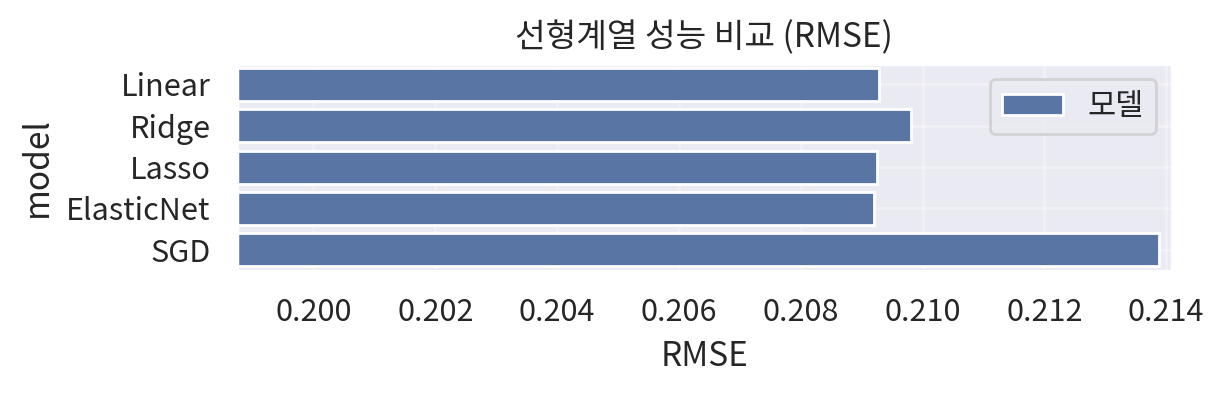

In [82]:
figsize = (1280 / my_dpi, 450 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# estimator : 요약식(np.mean, np.median, np.sum 등)
# errorbar : ('ci', 95)기본값, 'sd'표준편차, None없음
sb.barplot(data=diff_df, x="평균오차(RMSE)", y=diff_df.index, label="모델")

ax.set_title("선형계열 성능 비교 (RMSE)")
ax.set_xlabel("RMSE")
ax.set_ylabel("model")
ax.grid(True, alpha=0.3)
ax.set_xlim(
    diff_df["평균오차(RMSE)"].min() * 0.95, diff_df["평균오차(RMSE)"].max() * 1.001
)

plt.tight_layout()
plt.show()
plt.close()


## ✏️💡 인사이트

### 📊 1) 종합적인 기준

- **Linear 또는 ElasticNet 모델 채택 권장**
  - R² = 0.709로 가장 높은 설명력을 보임
  - RMSE = 0.204로 우수한 예측 정확도
  - MAPE = 0.310으로 상대적 오차율이 낮음

- **모델 간 성능 차이가 미미함**
  - R² 차이: 0.697 ~ 0.709 (최대 1.2%p)
  - RMSE 차이: 0.204 ~ 0.208 (최대 0.004)
  - 규제 기반 적용 시에도 성능 차이 거의 없음

- **SGD 모델은 상대적으로 열위**
  - 모든 지표에서 최저 성능
  - MPE = 0.53%로 체계적 편향 가능성

---

### 📉 2) RMSE 중심 기준

- **Linear, Ridge, ElasticNet 동일 우위**
  - 세 모델 모두 RMSE = 0.204로 동일
  - 실용적 차이 없음

- **Lasso는 근소하게 열위**
  - RMSE = 0.205 (0.001 차이)
  - 변수 선택 효과로 다중 손실이 미세하게 발생

- **SGD는 RMSE 관점에서도 최저**
  - RMSE = 0.208 약 2% 높은 오차

---




## 🎯 미션 5. 팀에 보고할 최종 모델을 하나 고르자

과적합이 발생하지 않으면서 테스트 성능이 가장 안정적인 모델을 하나 선택하라.

선택 기준에는 반드시 다음이 포함되어야 한다.

- 성능 지표  
- 일반화 안정성  
- 해석 가능성  

⚠️ 본 과제는 정답이 하나로 정해진 문제가 아님  
동일한 데이터라도 판단 기준과 설명 논리에 따라 다른 결론이 가능

📌 **출제 의도**  
실무에서의 모델 선택은 기술 문제가 아니라 의사결정 문제임을 인식시키기 위함입니다.

### 과적합 판정 함수

In [87]:
def hs_learning_cv(
    estimator,
    x,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
):
    train_sizes, train_scores, cv_scores = learning_curve(
        estimator=estimator,
        X=x,
        y=y,
        train_sizes=train_sizes,
        cv=cv,
        scoring=scoring,
        n_jobs=n_jobs,
        shuffle=True,
        random_state=52,
    )

    model_name = estimator.named_steps["model"].__class__.__name__
    print(f"=== Learning Curve: {model_name} ===")

    # neg RMSE -> RMSE
    train_rmse = -train_scores
    cv_rmse = -cv_scores

    # 평균 / 표준편차
    train_mean = train_rmse.mean(axis=1)
    cv_mean = cv_rmse.mean(axis=1)
    cv_std = cv_rmse.std(axis=1)

    # 마지막 지점 기준 값만 가져옴
    final_train = train_mean[-1]
    final_cv = cv_mean[-1]
    final_std = cv_std[-1]

    gap_ratio = final_train / final_cv
    var_ratio = final_std / final_cv

    # -------------------------
    # 과적합 기준 (some_threshold)
    # -------------------------

    # 기준 RMSE (평균 예측)
    y_mean = y.mean()
    rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

    # 분산 기반
    std_y = y.std()

    # 최소 설명력(R2) 기반
    min_r2 = 0.10
    rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

    # 최종 threshold (가장 관대한 기준)
    some_threshold = min(rmse_naive, std_y, rmse_r2)

    # -------------------------
    # 판정 로직
    # -------------------------
    if gap_ratio >= 0.95 and final_cv > some_threshold:
        status = "🟥 과소적합 (bias 큼)"
    elif gap_ratio <= 0.8:
        status = "🟥 과적합 (variance 큼)"
    elif gap_ratio <= 0.95 and var_ratio <= 0.10:
        status = "✅ 일반화 양호"
    elif var_ratio > 0.15:
        status = "🟨 데이터 부족 / 분산 큼"
    else:
        status = "🟨 판단 유보"

    # -------------------------
    # 정량 결과 표
    # -------------------------
    result_df = DataFrame(
        {
            "지표": [
                "Train RMSE",
                "CV RMSE 평균",
                "CV RMSE 표준편차",
                "Train/CV 비율",
                "CV 변동성 비율",
                "판정 결과",
            ],
            "값": [
                final_train,
                final_cv,
                final_std,
                gap_ratio,
                var_ratio,
                status,
            ],
        }
    )

    display(result_df)

    # -------------------------
    # 학습곡선 시각화
    # -------------------------
    figsize = (1280 / my_dpi, 720 / my_dpi)
    fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

    sb.lineplot(
        x=train_sizes,
        y=train_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="Train RMSE",
    )

    sb.lineplot(
        x=train_sizes,
        y=cv_mean,
        marker="o",
        markeredgecolor="#ffffff",
        label="CV RMSE",
    )

    ax.set_xlabel("학습 데이터 크기", fontsize=8, labelpad=5)
    ax.set_ylabel("RMSE (Learning Curve)", fontsize=8, labelpad=5)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close()


### [2] 훈련 모델별 과적합 판정

=== Learning Curve: LinearRegression ===


,지표,값
0,Train RMSE,0.197552
1,CV RMSE 평균,0.203111
2,CV RMSE 표준편차,0.01215
3,Train/CV 비율,0.97263
4,CV 변동성 비율,0.059819
5,판정 결과,🟨 판단 유보


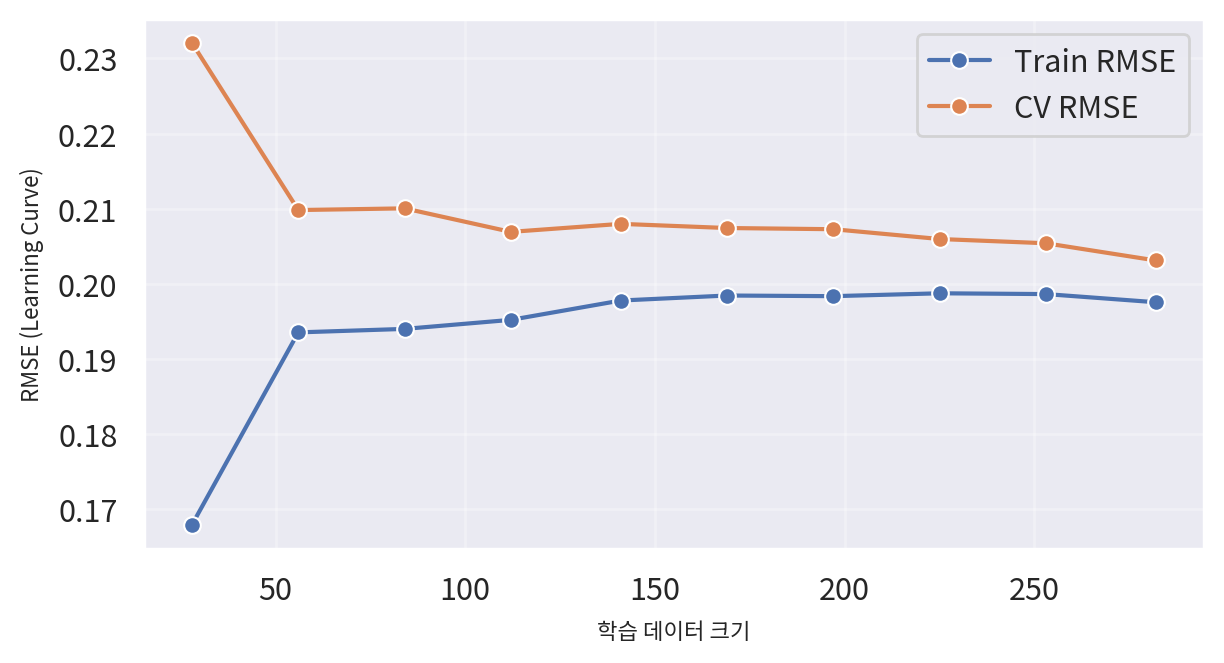

=== Learning Curve: Ridge ===


,지표,값
0,Train RMSE,0.197661
1,CV RMSE 평균,0.203012
2,CV RMSE 표준편차,0.012136
3,Train/CV 비율,0.973641
4,CV 변동성 비율,0.059781
5,판정 결과,🟨 판단 유보


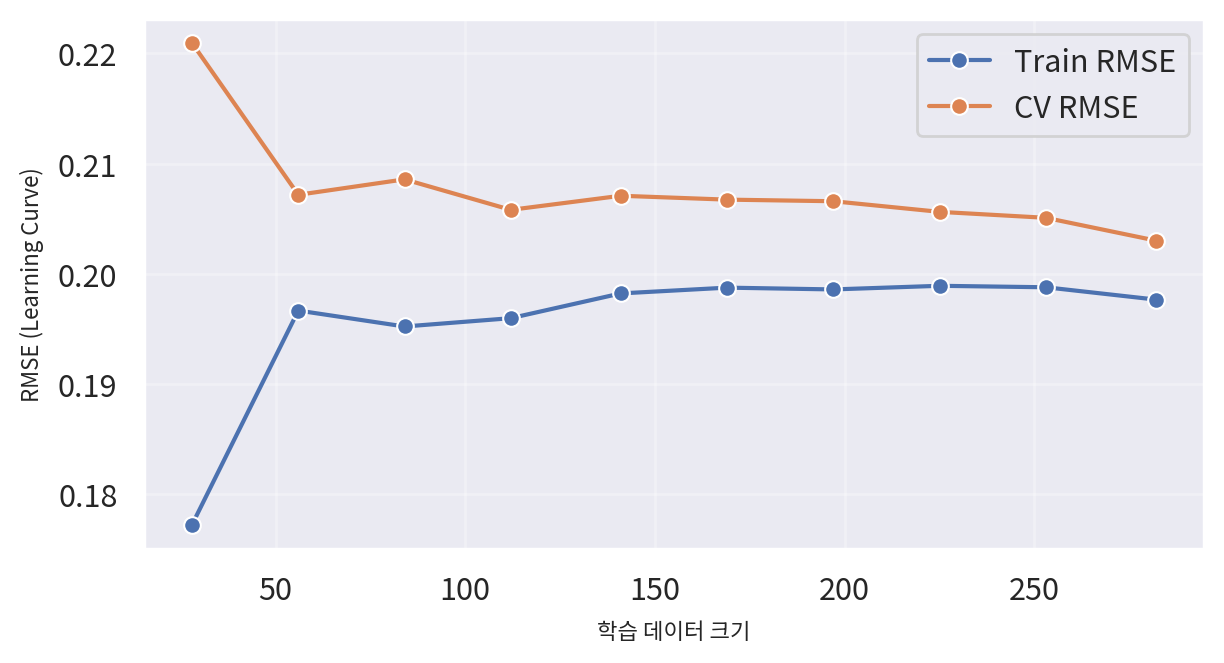

=== Learning Curve: Lasso ===


,지표,값
0,Train RMSE,0.199085
1,CV RMSE 평균,0.20364
2,CV RMSE 표준편차,0.011158
3,Train/CV 비율,0.977635
4,CV 변동성 비율,0.054793
5,판정 결과,🟨 판단 유보


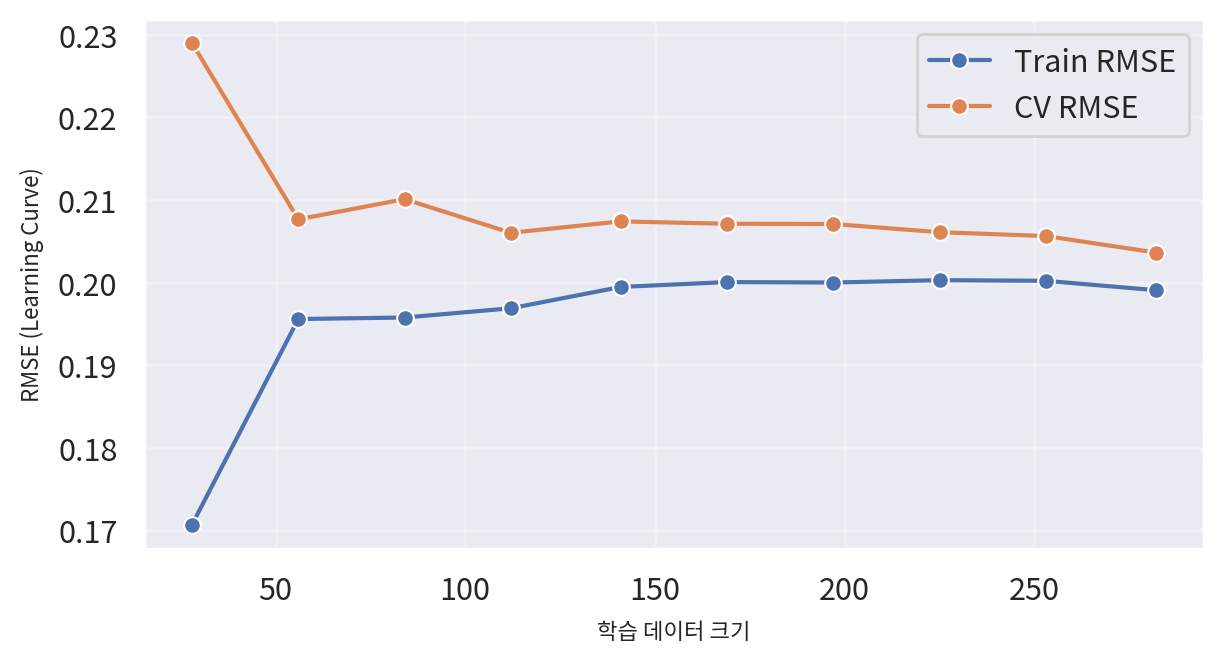

=== Learning Curve: ElasticNet ===


,지표,값
0,Train RMSE,0.197594
1,CV RMSE 평균,0.202956
2,CV RMSE 표준편차,0.012
3,Train/CV 비율,0.973582
4,CV 변동성 비율,0.059127
5,판정 결과,🟨 판단 유보


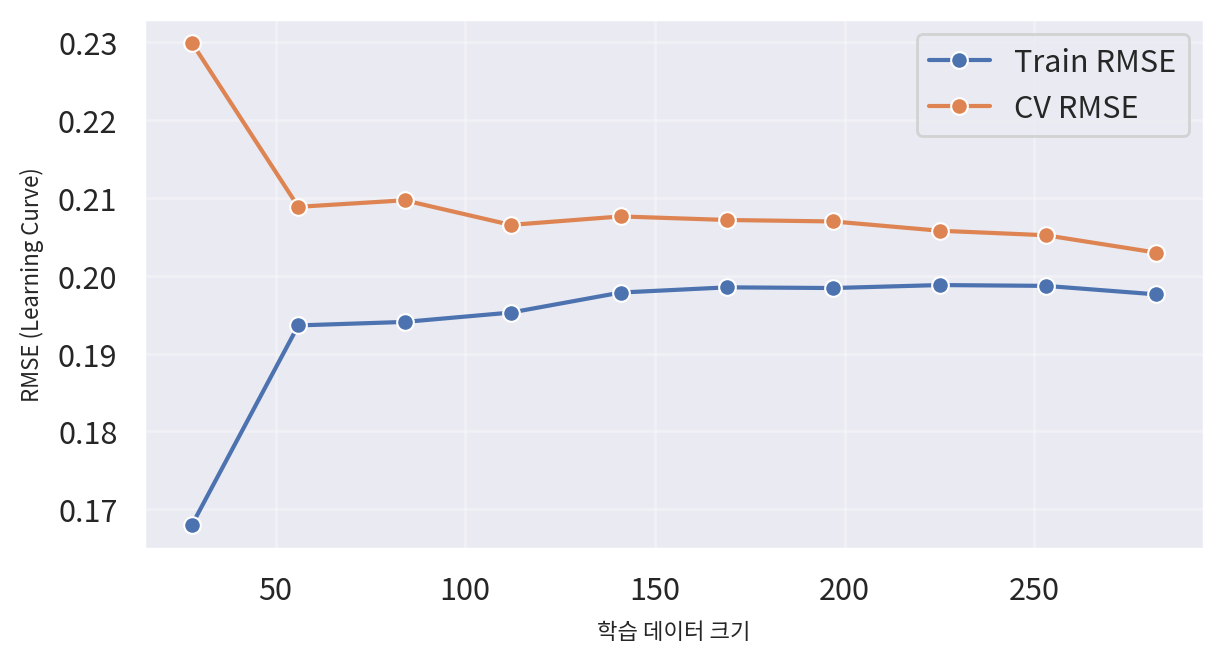

=== Learning Curve: SGDRegressor ===


,지표,값
0,Train RMSE,0.198632
1,CV RMSE 평균,0.203471
2,CV RMSE 표준편차,0.011989
3,Train/CV 비율,0.976219
4,CV 변동성 비율,0.058922
5,판정 결과,🟨 판단 유보


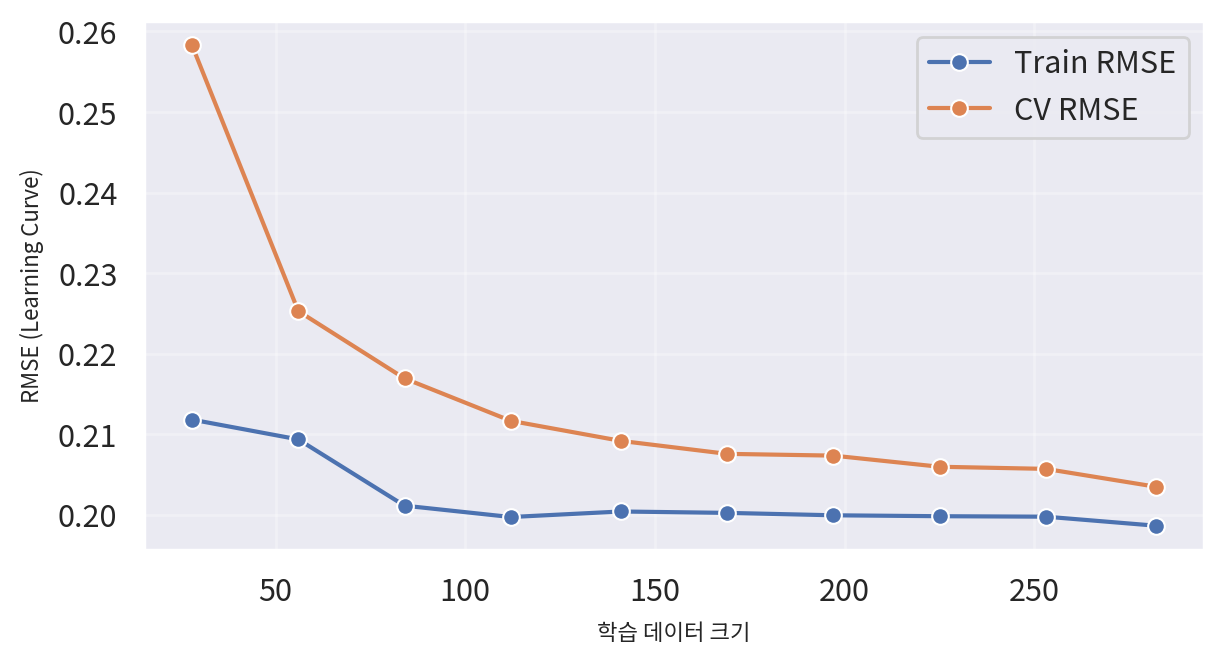

In [88]:
models = [
    linear_estimator,
    ridge_estimator,
    lasso_estimator,
    en_estimator,
    sgd_estimator,
]

for m in models:
    hs_learning_cv(estimator=m, x=x, y=y)


## ✏️💡 인사이트

✅ **최종 권장: Linear**

- CV RMSE 평균이 0.203으로 최저 수준(동률)
- CV RMSE 표준편차 0.012로 안정적
- 성능 동일하면 단순 모델이 우선 선택됨

---

## 🎯 미션 6. 이 모델은 설명 가능한가?

선택된 최종 모델에 대해 잔차 분석을 수행하여 회귀 가정을 점검하라.  
가정 위반이 있다면, 왜 발생했는지 실무적으로 얼마나 치명적인지를 중심으로 해석하라.

### 예) 위반 여부

- 예측값이 극단으로 치우치는가?  
- 특정 구간(고매출/저매출)에서만 발생하는가?  
- 정책·마케팅 의사결정에 영향을 주는가?

⚠️ 본 과제는 정답이 하나로 정해진 문제가 아님  
동일한 데이터라도 판단 기준과 설명 논리에 따라 다른 결론이 가능

📌 **출제 의도**  
예측 모델이라 하더라도, 설명 가능성 검토가 여전히 중요하다는 점을 강조하기 위함입니다.

### [1] 선형성

In [89]:
estimator = linear_estimator

rdf = x_train.copy()
rdf["sales"] = y_train

# 예측
rdf["y_pred"] = estimator.predict(x_train)

# 잔차
rdf["resid"] = rdf["sales"] - rdf["y_pred"]

rdf.head()


,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday_0,holiday_1,weekend_0,weekend_1,sales,y_pred,resid
date,,,,,,,,,,,,,
2024-10-12,127,18810,9.332646,0.46,0.875469,-5.3,0,1,0,1,16.854841,17.001954,-0.147113
2024-10-02,128,17520,9.417436,0.43,1.629241,-5.5,1,0,1,0,16.564443,16.301150,0.263293
2024-01-04,115,11160,8.748464,0.41,2.028148,12.9,1,0,1,0,16.082478,16.003086,0.079392
2024-12-03,115,17230,8.343078,0.69,1.740466,2.8,0,1,1,0,16.334678,16.326003,0.008674
2024-08-29,124,11480,8.699681,0.38,1.193922,1.2,1,0,1,0,16.317220,16.106321,0.210900


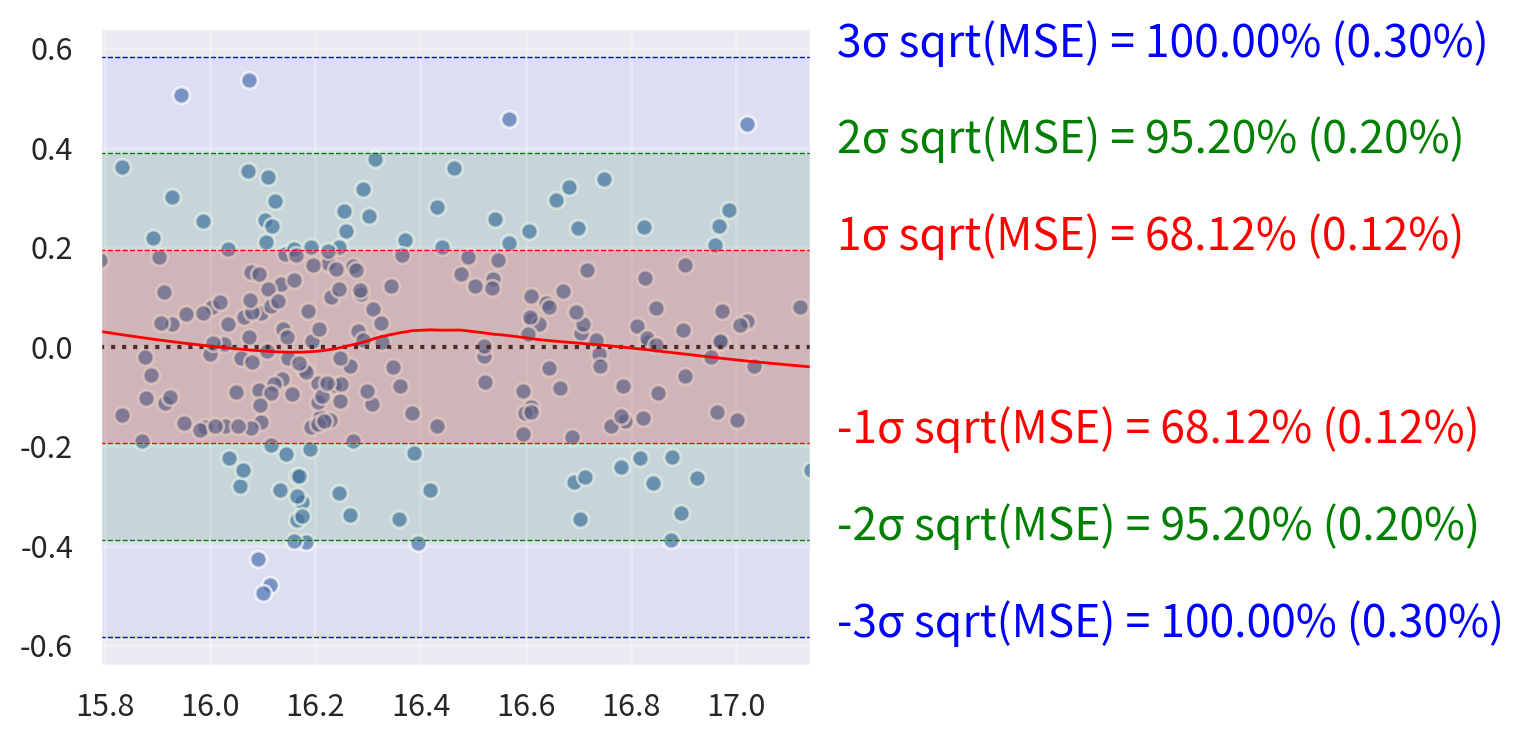

In [91]:
y = rdf["sales"].values
y_pred = rdf["y_pred"].values
resid = rdf["resid"].values

figsize = (1600 / my_dpi, 800 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# 잔차 산점도
sb.residplot(
    x=y_pred,
    y=resid,
    lowess=True,  # 추세선 표시
    line_kws={"color": "red", "linewidth": 1},  # 추세선 스타일
    scatter_kws={"edgecolor": "white", "alpha": 0.7},
)

# MSE표시
mse_val = mean_squared_error(y, y_pred)
mse_sq = np.sqrt(mse_val)

r1 = resid[(resid > -mse_sq) & (resid < mse_sq)].size / resid.size * 100
r2 = resid[(resid > -2 * mse_sq) & (resid < 2 * mse_sq)].size / resid.size * 100
r3 = resid[(resid > -3 * mse_sq) & (resid < 3 * mse_sq)].size / resid.size * 100

mse_r = [r1, r2, r3]

xmin, xmax = ax.get_xlim()

# 구간별 바탕 색상 채우기 (안쪽부터 바깥으로, 진한 색에서 연한 색으로)
colors = ["red", "green", "blue"]
alphas = [0.15, 0.10, 0.05]  # 안쪽이 더 진하게

# 3σ 이상 (가장 바깥, 가장 연함)
ax.axhspan(-3 * mse_sq, 3 * mse_sq, facecolor=colors[2], alpha=alphas[2], zorder=0)
# 2σ 이상 (중간)
ax.axhspan(-2 * mse_sq, 2 * mse_sq, facecolor=colors[1], alpha=alphas[1], zorder=1)
# 1σ 이상 (가장 안쪽, 가장 진함)
ax.axhspan(-mse_sq, mse_sq, facecolor=colors[0], alpha=alphas[0], zorder=2)

# 경계선 그리기
for i, c in enumerate(["red", "green", "blue"]):
    ax.axhline(mse_sq * (i + 1), color=c, linestyle="--", linewidth=0.5)
    ax.axhline(-mse_sq * (i + 1), color=c, linestyle="--", linewidth=0.5)

target = [68, 95, 99.7]
for i, c in enumerate(["red", "green", "blue"]):
    ax.text(
        s=f"{i+1}σ sqrt(MSE) = {mse_r[i]:.2f}% ({mse_r[i] - target[i]:.2f}%)",
        x=xmax + 0.05,
        y=(i + 1) * mse_sq,
        color=c,
    )

    ax.text(
        s=f"-{i+1}σ sqrt(MSE) = {mse_r[i]:.2f}% ({mse_r[i] - target[i]:.2f}%)",
        x=xmax + 0.05,
        y=-(i + 1) * mse_sq,
        color=c,
    )

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()


### [2] 정규성

In [92]:
residuals = rdf["resid"].values
n = len(residuals)
alpha = 0.05
results = []

# 1. Shapiro-Wilk 검정 (샘플크기 <= 5000일 때만 권장)
if n < 5000:
    try:
        stat_sw, p_sw = shapiro(residuals)
        significant_sw = p_sw <= alpha

        if significant_sw:
            interpretation_sw = f"정규성 위반 (p={p_sw:.4f} <= {alpha})"
        else:
            interpretation_sw = f"정규성 만족 (p={p_sw:.4f} > {alpha})"

        results.append(
            {
                "검정": "Shapiro-Wilk",
                "검정통계량": f"{stat_sw:.4f}",
                "p-value": f"{p_sw:.4f}",
                "유의수준": alpha,
                "정규성 위반": significant_sw,
                "해석": interpretation_sw,
            }
        )
    except Exception as e:
        pass

# 2. Jarque-Bera 검정 (항상 수행)
try:
    stat_jb, p_jb = jarque_bera(residuals)
    significant_jb = p_jb <= alpha

    if significant_jb:
        interpretation_jb = f"정규성 위반 (p={p_jb:.4f} <= {alpha})"
    else:
        interpretation_jb = f"정규성 만족 (p={p_jb:.4f} > {alpha})"

    results.append(
        {
            "검정": "Jarque-Bera",
            "검정통계량": f"{stat_jb:.4f}",
            "p-value": f"{p_jb:.4f}",
            "유의수준": alpha,
            "정규성 위반": significant_jb,
            "해석": interpretation_jb,
        }
    )
except Exception as e:
    pass

result_df = DataFrame(results)
result_df


,검정,검정통계량,p-value,유의수준,정규성 위반,해석
0,Shapiro-Wilk,0.9971,0.9524,0.05,False,정규성 만족 (p=0.9524 > 0.05)
1,Jarque-Bera,0.4693,0.7908,0.05,False,정규성 만족 (p=0.7908 > 0.05)


### [3] 등분산성

In [93]:
resid = rdf["resid"]
alpha = 0.05
results = []

exog = rdf.drop(columns=[yname, "y_pred", "resid"])
exog = sm.add_constant(exog)
exog.head()

# 1. Breusch-Pagan 검정
try:
    lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(resid, exog)
    significant_bp = lm_pvalue <= alpha

    if significant_bp:
        interpretation_bp = f"등분산성 위반 (p={lm_pvalue:.4f} <= {alpha})"
    else:
        interpretation_bp = f"등분산성 만족 (p={lm_pvalue:.4f} > {alpha})"

    results.append(
        {
            "검정": "Breusch-Pagan",
            "검정통계량 (LM)": f"{lm:.4f}",
            "p-value": f"{lm_pvalue:.4f}",
            "유의수준": alpha,
            "등분산성_위반": significant_bp,
            "해석": interpretation_bp,
        }
    )
except Exception as e:
    pass

# 2. White 검정
try:
    lm, lm_pvalue, fvalue, f_pvalue = het_white(resid, exog)
    significant_white = lm_pvalue <= alpha

    if significant_white:
        interpretation_white = f"등분산성 위반 (p={lm_pvalue:.4f} <= {alpha})"
    else:
        interpretation_white = f"등분산성 만족 (p={lm_pvalue:.4f} > {alpha})"

    results.append(
        {
            "검정": "White",
            "검정통계량 (LM)": f"{lm:.4f}",
            "p-value": f"{lm_pvalue:.4f}",
            "유의수준": alpha,
            "등분산성_위반": significant_white,
            "해석": interpretation_white,
        }
    )
except Exception as e:
    pass

result_df = DataFrame(results)
result_df


,검정,검정통계량 (LM),p-value,유의수준,등분산성_위반,해석
0,Breusch-Pagan,4.3771,0.9287,0.05,False,등분산성 만족 (p=0.9287 > 0.05)
1,White,29.2623,0.9147,0.05,False,등분산성 만족 (p=0.9147 > 0.05)


### [4] 독립성

In [94]:
# Durbin-Watson 통계량 계산
dw_stat = durbin_watson(rdf["resid"])

# 자기상관 판단 (1.5 < DW < 2.5 범위를 독립성 만족으로 판단)
is_autocorrelated = dw_stat < 1.5 or dw_stat > 2.5

# 해석 메시지 생성
if dw_stat < 1.5:
    interpretation = f"DW={dw_stat:.4f} < 1.5 (양의 자기상관)"
elif dw_stat > 2.5:
    interpretation = f"DW={dw_stat:.4f} > 2.5 (음의 자기상관)"
else:
    interpretation = f"DW={dw_stat:.4f} (독립성 가정 만족)"

# 결과 데이터프레임 생성
result_df = DataFrame(
    {
        "검정": ["Durbin-Watson"],
        "검정통계량 (DW)": [dw_stat],
        "독립성_위반": [is_autocorrelated],
        "해석": [interpretation],
    }
)

result_df


,검정,검정통계량 (DW),독립성_위반,해석
0,Durbin-Watson,1.939036,False,DW=1.9390 (독립성 가정 만족)


## 🎯 미션 7. 최종 결과 보고

모형의 성능, 일반화 안정성, 모형 적합도, 독립변수 보고에 대해 정리하여 보고하라.

⚠️ 본 과제는 정답이 하나로 정해진 문제가 아님  
동일한 데이터라도 판단 기준과 설명 논리에 따라 다른 결론이 가능

📌 **출제 의도**  
분석 결과에 반드시 포함되어야 하는 항목을 강조하기 위함입니다.


### [1] 모형 적합도 보고

In [97]:
# 잔차 분석용 예측값 및 잔차 계산
y_train_pred = estimator.predict(x_train)
resid = y_train - y_train_pred

# Durbin-Watson 통계량 계산
dw = durbin_watson(resid)

# 결정계수 및 조정된 결정계수 계산
xnames = x_train.columns.tolist()
r2 = r2_score(y_train, y_train_pred)
r = np.sqrt(r2)
adj_r2 = 1 - (1 - r2) * (len(y_train) - 1) / (len(y_train) - len(xnames) - 1)

# F-statistic
rowcount = len(x_train)
featurecount = len(xnames)
f_statistic = (r2 / featurecount) / ((1 - r2) / (rowcount - featurecount - 1))

# p-value 계산
p = 1 - f.cdf(f_statistic, featurecount, rowcount - featurecount - 1)

# 결과 데이터프레임 생성
rdf = DataFrame(
    {
        "R": [r],
        "R2": [r2],
        "Adj R2": [adj_r2],
        "F": [f_statistic],
        "p-value": [p],
        "Durbin-Watson": [dw],
    }
)

rdf


,R,R2,Adj R2,F,p-value,Durbin-Watson
0,0.860374,0.740243,0.728328,62.124683,1.110223e-16,1.939036


In [98]:
tpl = "R(%.3f), R²(%.3f), Adj R²(%.3f), F(%.3f), P-value(%.3f), Durbin-Watson(%.3f)"
tpl % (r, r2, adj_r2, f_statistic, p, dw)


'R(0.860), R²(0.740), Adj R²(0.728), F(62.125), P-value(0.000), Durbin-Watson(1.939)'

In [99]:
tpl = "%s에 대하여 %s로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 %s (F(%s,%s) = %0.3f, p %s 0.05)."

tpl % (
    yname,
    ", ".join(xnames),
    "유의하다" if p <= 0.05 else "유의하지 않다",
    len(x_train.columns),
    len(x_train.index) - len(x_train.columns) - 1,
    f_statistic,
    "<=" if p <= 0.05 else ">",
)


'sales에 대하여 visitors, avg_price, marketing_cost, delivery_ratio, rain_mm, temperature, holiday_0, holiday_1, weekend_0, weekend_1로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 유의하다 (F(10,218) = 62.125, p <= 0.05).'

### [2] 독립변수 보고

In [100]:
# 절편과 계수를 하나의 벡터로 결합
# GridSearchCV를 사용한 경우
params = np.append(
    estimator.named_steps["model"].intercept_, estimator.named_steps["model"].coef_
)

# 독립변수에 상수항 추가
design_x = x_train.copy()
design_x = sm.add_constant(design_x)

# X'X 행렬
dot = np.dot(design_x.T, design_x)

# (X'X)^(-1)
inv = np.linalg.inv(dot)

# 대각 원소
dia = inv.diagonal()

# 평균제곱오차
predictions = estimator.predict(x_train)
n = design_x.shape[0]  # 샘플 수
p = design_x.shape[1]  # 변수 수 (상수항 포함)
MSE = ((y_train - predictions) ** 2).sum() / (n - p)

# 표준오차
se_b = np.sqrt(MSE * dia)

# t-통계량
ts_b = params / se_b

# p-값
n = design_x.shape[0]
p = design_x.shape[1]
p_values = [2 * (1 - t.cdf(np.abs(i), n - p)) for i in ts_b]

# VIF 계산
vif = []
x_con = sm.add_constant(x_train)

for j, v in enumerate(xnames):
    vif.append(variance_inflation_factor(x_con.values, j + 1))

# 표준화 계수(베타) 구하기
tmp_df = x_train.copy()
tmp_df[yname] = y_train

scaler = StandardScaler()
std = scaler.fit_transform(tmp_df)
std_df = DataFrame(std, columns=tmp_df.columns)

std_x = std_df.drop(columns=[yname])
std_y = std_df[yname]

estimator.fit(std_x, std_y)

# GridSearchCV 사용한 경우
beta = estimator.named_steps["model"].coef_

# 결과표 작성
result_df = DataFrame(
    {
        "종속변수": [yname] * len(xnames),
        "독립변수": xnames,
        "B(비표준화 계수)": np.round(params[1:], 4),
        "표준오차": np.round(se_b[1:], 4),
        "β(표준화 계수)": np.round(beta, 4),
        "t": np.round(ts_b[1:], 4),
        "유의확률": np.round(p_values[1:], 4),
        "VIF": np.round(vif, 4),
    }
)

# 유의확률에 따른 별표 추가
result_df["t"] = result_df["t"].astype("str") + result_df["유의확률"].apply(
    lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
)

result_df



VIF 제거 반복 1회차 =================
모든 변수의 VIF가 임계값 이하가 되어 종료합니다. 제거된 변수 0개


C:\Users\itwill\AppData\Local\Temp\ipykernel_8712\4087687913.py:27: RuntimeWarning: invalid value encountered in sqrt
  se_b = np.sqrt(MSE * dia)
c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,종속변수,독립변수,B(비표준화 계수),표준오차,β(표준화 계수),t,유의확률,VIF
0,sales,visitors,0.0449,1.200000e-03,0.1178,36.4802***,0.0000,1.0188
1,sales,avg_price,0.0750,0.000000e+00,0.1965,21111.8534***,0.0000,1.0342
2,sales,marketing_cost,0.1010,2.200000e-02,0.2647,4.5854***,0.0000,1.0119
3,sales,delivery_ratio,0.0053,1.132000e-01,0.0138,0.0466,0.9628,1.0202
4,sales,rain_mm,-0.0733,2.100000e-02,-0.1921,-3.4935***,0.0006,1.0459
5,sales,temperature,0.0238,1.200000e-03,0.0625,19.1058***,0.0000,1.0111
6,sales,holiday_0,-0.0595,2.363804e+06,-0.1560,-0.0,1.0000,inf
7,sales,holiday_1,0.0595,2.363804e+06,0.1560,0.0,1.0000,inf
8,sales,weekend_0,-0.0828,1.181902e+06,-0.2172,-0.0,1.0000,inf
9,sales,weekend_1,0.0828,1.181902e+06,0.2172,0.0,1.0000,inf


In [101]:
varstr = []

for n in xnames:
    item = result_df[result_df["독립변수"] == n]
    coef = float(item["B(비표준화 계수)"].values[0])
    pvalue = float(item["유의확률"].values[0])

    s = "%s가 1증가하면 %s (이)가 %.3f만큼 변하는 것으로 나타남 (p %s 0.05, %s)" % (
        n,
        yname,
        coef,
        "<=" if pvalue <= 0.05 else ">",
        "유의함" if pvalue <= 0.05 else "유의하지 않음",
    )

    varstr.append(s)

varstr


['visitors가 1증가하면 sales (이)가 0.045만큼 변하는 것으로 나타남 (p <= 0.05, 유의함)',
 'avg_price가 1증가하면 sales (이)가 0.075만큼 변하는 것으로 나타남 (p <= 0.05, 유의함)',
 'marketing_cost가 1증가하면 sales (이)가 0.101만큼 변하는 것으로 나타남 (p <= 0.05, 유의함)',
 'delivery_ratio가 1증가하면 sales (이)가 0.005만큼 변하는 것으로 나타남 (p > 0.05, 유의하지 않음)',
 'rain_mm가 1증가하면 sales (이)가 -0.073만큼 변하는 것으로 나타남 (p <= 0.05, 유의함)',
 'temperature가 1증가하면 sales (이)가 0.024만큼 변하는 것으로 나타남 (p <= 0.05, 유의함)',
 'holiday_0가 1증가하면 sales (이)가 -0.059만큼 변하는 것으로 나타남 (p > 0.05, 유의하지 않음)',
 'holiday_1가 1증가하면 sales (이)가 0.059만큼 변하는 것으로 나타남 (p > 0.05, 유의하지 않음)',
 'weekend_0가 1증가하면 sales (이)가 -0.083만큼 변하는 것으로 나타남 (p > 0.05, 유의하지 않음)',
 'weekend_1가 1증가하면 sales (이)가 0.083만큼 변하는 것으로 나타남 (p > 0.05, 유의하지 않음)']